# Multi-Fidelity Neural Networks

This section provides implementation for concepts related to multi-fidelity neural network models. Make sure that you have downloaded and installed the latest release of the `scimlstudio` package before running the code in this section. Go through [neural network section](nn_models.ipynb) before you proceed further. In this section, we will be focusing on multi-fidelity neural network (MFNN) framework proposed by [Meng and Karniadakis](https://doi.org/10.1016/j.jcp.2019.109020). This work proposes to learn the correlation between fidelities using a general function $F$. Mathematically, the correlation is written as

$$
    y_H = \mathcal{F}(\mathbf{x},y_L(\mathbf{x})),
$$

where $y_H$ and $y_L$ represents high and low fidelity data, and $\mathbf{x}$ denotes design variable vector. The function $\mathcal{F}$ is further decomposed into two parts: linear and nonlinear correlation, and is written as

$$
    \mathcal{F} = \mathcal{F}_L + \mathcal{F}_{NL}.
$$

The $\mathcal{F}_L$ and $\mathcal{F}_{NL}$ denote linear and nonlinear correlation function, respectively. Both these functions are approximated using a neural network model. Additionally, the relation $\mathbf{x}$ and $y_L$ is also modeled using a neural network. These networks are arranged as shown in below schematic.

```{image} images/mf_net.png
:width: 450px
:align: center
```

As mentioned earlier, there are three sub-networks here:

- $\mathcal{NN}_L$: learns mapping between $\mathbf{x}$ and $y_L$
- $\mathcal{NN}_{H_1}$: learns linear correlation between $y_L$ and $y_H$
- $\mathcal{NN}_{H_2}$: learns nonlinear correlation between $y_L$ and $y_H$

> __NOTE__: The design variables can be different for low and high-fidelity data. In this demonstration, it is assumed to be same.

To demonstrate MFNN, we will be using following function:

$$

$$

Following code block imports required functions:

In [16]:
import torch
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
args = {
    "device": device,
    "dtype": dtype
}

Next block defines low and high fidelity functions:

In [ ]:
def low_fidelity(x):
    mask = x <= 0.5
    y = 0.5*(6*x - 2)**2 * torch.sin(12*x - 4) + 10*(x - 0.5) - 5
    y[~mask] = 3 + y[~mask]
    return y

def high_fidelity(x):
    mask = x <= 0.5
    y = 2*low_fidelity(x) - 20*x + 20
    y[~mask] = 4 + y[~mask]
    return y

Next block defines training and testing (or plotting) data:

In [ ]:
# low fidelity training data
x_lf = torch.cat((torch.linspace(0, 0.35, 8), torch.linspace(0.4, 0.6, 22), torch.linspace(0.65, 1.0, 8)), axis=0).to(**args).reshape(-1,1)
y_lf = low_fidelity(x_lf)

# high fidelity training data
x_hf = torch.tensor([0.2, 0.4, 0.6, 0.7, 0.9], **args).reshape(-1,1)
y_hf = high_fidelity(x_hf)


x_test = torch.linspace(0, 1, 100, **args).reshape(-1,1)
y_test_lf = low_fidelity(x_test)
y_test_hf = high_fidelity(x_test)

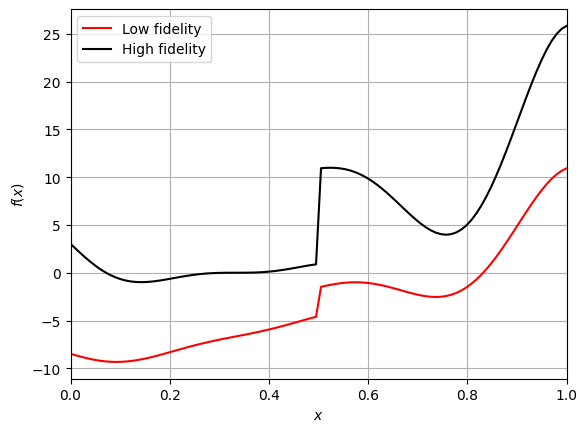

In [15]:
plt.plot(x_test.numpy(force=True), y_test_lf.numpy(force=True), "r-", label="Low fidelity")

plt.plot(x_test.numpy(force=True), y_test_hf.numpy(force=True), "k-", label="High fidelity")

plt.xlabel("$x$")

plt.ylabel("$f(x)$")

plt.xlim(left=0.0, right=1.0)

plt.grid()

plt.legend()